<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Arabic_Sentiment_Analysis_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# تثبيت المكتبات المطلوبة
!pip install camel-tools scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ كل المكتبات جاهزة!")

✅ كل المكتبات جاهزة!


In [3]:
# إنشاء مجموعة بيانات عربية للتدريب
data = {
    'text': [
        # إيجابية 😊
        'هذا المنتج رائع جداً وأنصح به الجميع',
        'خدمة ممتازة وسريعة شكراً جزيلاً',
        'تجربة جميلة سأكرر الشراء مرة أخرى',
        'جودة عالية وسعر مناسب أحسنتم',
        'فريق العمل محترف ومتعاون جداً',
        'المنتج وصل بسرعة وحالته ممتازة',
        'أفضل تجربة تسوق في حياتي',
        'سعيد جداً بهذا الاختيار',
        'خدمة عملاء رائعة وسريعة الاستجابة',
        'المنتج يفوق التوقعات بكثير',
        'نوعية ممتازة وتغليف احترافي',
        'شكراً على الخدمة الرائعة والسريعة',
        'تجربة ممتعة سأنصح أصدقائي بها',
        'المنتج مطابق للوصف تماماً ورائع',
        'خدمة استثنائية لم أتوقعها أبداً',

        # سلبية 😞
        'منتج سيء جداً لا أنصح به أبداً',
        'خدمة بطيئة ومزعجة للغاية',
        'جودة رديئة لا تستحق السعر',
        'تجربة مروعة لن أكررها مطلقاً',
        'فريق العمل غير محترف ومهمل',
        'المنتج وصل تالفاً وبحالة سيئة',
        'أسوأ تجربة تسوق في حياتي',
        'غير راضٍ عن هذا المنتج إطلاقاً',
        'خدمة عملاء سيئة لا تستجيب',
        'المنتج لا يعمل كما هو موضح',
        'نوعية رديئة وتغليف مكسور',
        'لن أشتري من هذا المتجر مجدداً',
        'تجربة مزعجة ومحبطة للغاية',
        'المنتج مختلف تماماً عن الوصف',
        'خدمة مخيبة للآمال جداً',
    ],
    'label': [1]*15 + [0]*15  # 1=إيجابي, 0=سلبي
}

df = pd.DataFrame(data)
print(f"✅ تم إنشاء {len(df)} جملة للتدريب")
print(f"😊 إيجابية: {df['label'].sum()}")
print(f"😞 سلبية: {len(df) - df['label'].sum()}")
df.head(5)

✅ تم إنشاء 30 جملة للتدريب
😊 إيجابية: 15
😞 سلبية: 15


,text,label
0,هذا المنتج رائع جداً وأنصح به الجميع,1
1,خدمة ممتازة وسريعة شكراً جزيلاً,1
2,تجربة جميلة سأكرر الشراء مرة أخرى,1
3,جودة عالية وسعر مناسب أحسنتم,1
4,فريق العمل محترف ومتعاون جداً,1


In [4]:
# دالة تنظيف النص العربي
def clean_arabic(text):
    # إزالة التشكيل
    text = re.sub(r'[\u064B-\u065F]', '', text)
    # إزالة الأرقام
    text = re.sub(r'\d+', '', text)
    # إزالة الرموز والعلامات
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    # إزالة المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# تطبيق التنظيف على البيانات
df['text_clean'] = df['text'].apply(clean_arabic)

print("✅ تم تنظيف النصوص!")
print("\n📋 مثال قبل وبعد التنظيف:")
print(f"قبل : {df['text'][0]}")
print(f"بعد : {df['text_clean'][0]}")

✅ تم تنظيف النصوص!

📋 مثال قبل وبعد التنظيف:
قبل : هذا المنتج رائع جداً وأنصح به الجميع
بعد : هذا المنتج رائع جدا وأنصح به الجميع


In [5]:
# تحويل النص لأرقام
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text_clean'])
y = df['label']

# تقسيم البيانات للتدريب والاختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# تدريب النموذج
model = LogisticRegression()
model.fit(X_train, y_train)

# قياس الدقة
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ تم تدريب النموذج بنجاح!")
print(f"🎯 دقة النموذج: {accuracy:.2%}")
print("\n📊 تقرير مفصل:")
print(classification_report(y_test, y_pred,
      target_names=['😞 سلبي', '😊 إيجابي']))

✅ تم تدريب النموذج بنجاح!
🎯 دقة النموذج: 50.00%

📊 تقرير مفصل:
              precision    recall  f1-score   support

      😞 سلبي       1.00      0.25      0.40         4
    😊 إيجابي       0.40      1.00      0.57         2

    accuracy                           0.50         6
   macro avg       0.70      0.62      0.49         6
weighted avg       0.80      0.50      0.46         6



In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# إضافة بيانات أكثر
extra_data = {
    'text': [
        'أحببت هذا المنتج كثيراً وسأشتريه مجدداً',
        'ممتاز ومريح وسهل الاستخدام',
        'رائع جداً وأنصح به بشدة',
        'جيد جداً وسعره معقول',
        'أفضل منتج اشتريته هذا العام',
        'سعيد جداً بالشراء لن أندم',
        'خدمة ودية ومنتج عالي الجودة',
        'تجربة ممتعة ومريحة للغاية',
        'وصل بسرعة والجودة ممتازة جداً',
        'أنصح الجميع بهذا المنتج الرائع',
        'مزيف وغير أصلي ولا يستحق',
        'سيء جداً ولن أشتري مرة أخرى',
        'مخيب للآمال والجودة رديئة',
        'تأخر كثيراً في التوصيل وتالف',
        'لا أنصح به أبداً تجربة سيئة',
        'رديء ولا يعمل بشكل صحيح',
        'مضيعة للمال والوقت لا تشتره',
        'غير مطابق للصور والوصف كذب',
        'فظيع ومحبط جداً لا تشتريه',
        'أسوأ منتج اشتريته في حياتي',
    ],
    'label': [1]*10 + [0]*10
}

df2 = pd.DataFrame(extra_data)
df2['text_clean'] = df2['text'].apply(clean_arabic)

# دمج البيانات
df_full = pd.concat([df, df2], ignore_index=True)

print(f"✅ إجمالي البيانات: {len(df_full)} جملة")
print(f"😊 إيجابية: {df_full['label'].sum()}")
print(f"😞 سلبية: {len(df_full) - df_full['label'].sum()}")

# إعادة التدريب بنموذج أقوى
X2 = vectorizer.fit_transform(df_full['text_clean'])
y2 = df_full['label']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# تجربة 3 نماذج مختلفة
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': MultinomialNB(),
    'Linear SVC': LinearSVC()
}

print("\n📊 مقارنة النماذج:")
print("-" * 35)
best_model = None
best_acc = 0

for name, m in models.items():
    m.fit(X_train2, y_train2)
    acc = accuracy_score(y_test2, m.predict(X_test2))
    print(f"  {name}: {acc:.2%}")
    if acc > best_acc:
        best_acc = acc
        best_model = m
        best_name = name

print("-" * 35)
print(f"\n🏆 أفضل نموذج: {best_name} بدقة {best_acc:.2%}")

✅ إجمالي البيانات: 50 جملة
😊 إيجابية: 25
😞 سلبية: 25

📊 مقارنة النماذج:
-----------------------------------
  Logistic Regression: 60.00%
  Naive Bayes: 50.00%
  Linear SVC: 70.00%
-----------------------------------

🏆 أفضل نموذج: Linear SVC بدقة 70.00%


In [7]:
# دالة التنبؤ بالمشاعر
def predict_sentiment(text):
    cleaned = clean_arabic(text)
    vector = vectorizer.transform([cleaned])
    result = best_model.predict(vector)[0]

    if result == 1:
        return f"😊 إيجابي"
    else:
        return f"😞 سلبي"

# اختبار بجمل حقيقية
test_sentences = [
    "هذا المنتج رائع جداً وأنصح به",
    "خدمة سيئة جداً لن أعود مرة أخرى",
    "تجربة ممتعة وسعر مناسب",
    "المنتج وصل تالفاً ومكسوراً",
    "شكراً على الخدمة الممتازة",
    "لا أنصح بهذا المتجر أبداً",
    "جودة عالية وتوصيل سريع",
    "مزيف وغير أصلي احذروا",
]

print("🧪 اختبار النموذج:")
print("=" * 45)
for sentence in test_sentences:
    result = predict_sentiment(sentence)
    print(f"  {result} ← {sentence}")
print("=" * 45)
print(f"\n✅ النموذج يعمل بدقة {best_acc:.2%}")

🧪 اختبار النموذج:
  😊 إيجابي ← هذا المنتج رائع جداً وأنصح به
  😞 سلبي ← خدمة سيئة جداً لن أعود مرة أخرى
  😊 إيجابي ← تجربة ممتعة وسعر مناسب
  😞 سلبي ← المنتج وصل تالفاً ومكسوراً
  😊 إيجابي ← شكراً على الخدمة الممتازة
  😞 سلبي ← لا أنصح بهذا المتجر أبداً
  😊 إيجابي ← جودة عالية وتوصيل سريع
  😞 سلبي ← مزيف وغير أصلي احذروا

✅ النموذج يعمل بدقة 70.00%


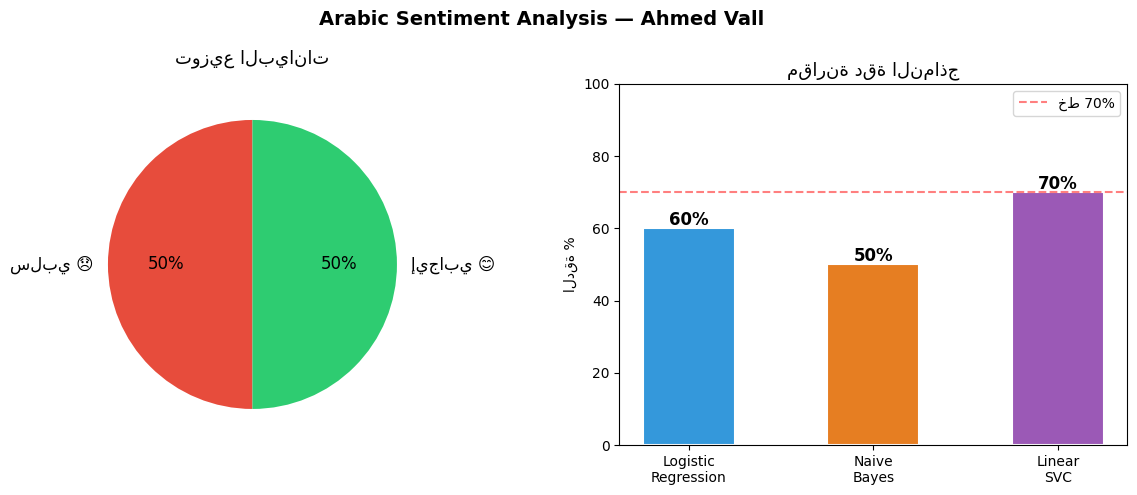

✅ تم حفظ الرسم البياني!


In [8]:
# رسم بياني للنتائج
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Arabic Sentiment Analysis — Ahmed Vall',
             fontsize=14, fontweight='bold')

# 1️⃣ توزيع البيانات
colors = ['#e74c3c', '#2ecc71']
labels = ['سلبي 😞', 'إيجابي 😊']
counts = [len(df_full[df_full['label']==0]),
          len(df_full[df_full['label']==1])]

axes[0].pie(counts, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('توزيع البيانات', fontsize=13, pad=15)

# 2️⃣ مقارنة دقة النماذج
model_names = ['Logistic\nRegression', 'Naive\nBayes', 'Linear\nSVC']
accuracies = []
for name, m in models.items():
    acc = accuracy_score(y_test2, m.predict(X_test2))
    accuracies.append(acc * 100)

bar_colors = ['#3498db', '#e67e22', '#9b59b6']
bars = axes[1].bar(model_names, accuracies,
                    color=bar_colors, width=0.5,
                    edgecolor='white', linewidth=1.5)

# إضافة النسب فوق الأعمدة
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{acc:.0f}%', ha='center',
                 fontweight='bold', fontsize=12)

axes[1].set_title('مقارنة دقة النماذج', fontsize=13)
axes[1].set_ylabel('الدقة %')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=70, color='red', linestyle='--',
                alpha=0.5, label='خط 70%')
axes[1].legend()

plt.tight_layout()
plt.savefig('sentiment_results.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ تم حفظ الرسم البياني!")

In [9]:
import pickle
from google.colab import files

# حفظ النموذج
with open('arabic_sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# حفظ الـ vectorizer
with open('arabic_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("✅ تم حفظ النموذج بنجاح!")
print("✅ تم حفظ الـ vectorizer!")

# تحميل الملفات
files.download('arabic_sentiment_model.pkl')
files.download('arabic_vectorizer.pkl')
files.download('sentiment_results.png')

print("\n🎉 تم تحميل كل الملفات!")
print("📁 الملفات الجاهزة:")
print("  - arabic_sentiment_model.pkl  ← النموذج")
print("  - arabic_vectorizer.pkl       ← المحول")
print("  - sentiment_results.png       ← الرسم البياني")

✅ تم حفظ النموذج بنجاح!
✅ تم حفظ الـ vectorizer!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 تم تحميل كل الملفات!
📁 الملفات الجاهزة:
  - arabic_sentiment_model.pkl  ← النموذج
  - arabic_vectorizer.pkl       ← المحول
  - sentiment_results.png       ← الرسم البياني


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 2.4 MB/s eta 0:00:00


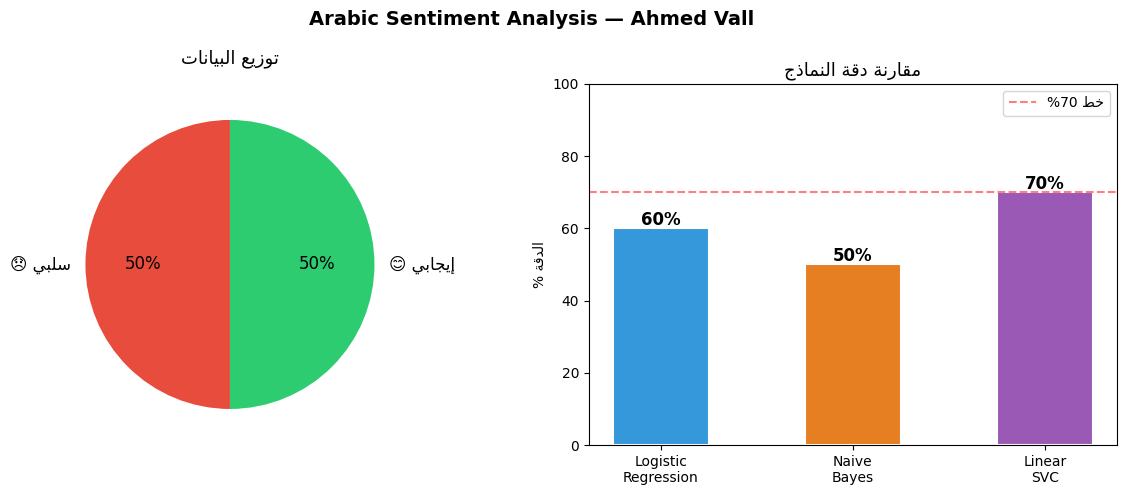

✅ تم إصلاح العربية وحفظ الرسم!


In [10]:
!pip install arabic-reshaper python-bidi -q

import arabic_reshaper
from bidi.algorithm import get_display

def ar(text):
    return get_display(arabic_reshaper.reshape(text))

# إعادة رسم المخطط بعربية صحيحة
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Arabic Sentiment Analysis — Ahmed Vall',
             fontsize=14, fontweight='bold')

# 1️⃣ توزيع البيانات
colors = ['#e74c3c', '#2ecc71']
labels = [ar('سلبي 😞'), ar('إيجابي 😊')]
counts = [len(df_full[df_full['label']==0]),
          len(df_full[df_full['label']==1])]

axes[0].pie(counts, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title(ar('توزيع البيانات'), fontsize=13, pad=15)

# 2️⃣ مقارنة دقة النماذج
model_names = ['Logistic\nRegression', 'Naive\nBayes', 'Linear\nSVC']
accuracies = []
for name, m in models.items():
    acc = accuracy_score(y_test2, m.predict(X_test2))
    accuracies.append(acc * 100)

bar_colors = ['#3498db', '#e67e22', '#9b59b6']
bars = axes[1].bar(model_names, accuracies,
                    color=bar_colors, width=0.5,
                    edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{acc:.0f}%', ha='center',
                 fontweight='bold', fontsize=12)

axes[1].set_title(ar('مقارنة دقة النماذج'), fontsize=13)
axes[1].set_ylabel(ar('الدقة %'))
axes[1].set_ylim(0, 100)
axes[1].axhline(y=70, color='red', linestyle='--',
                alpha=0.5, label=ar('خط 70%'))
axes[1].legend()

plt.tight_layout()
plt.savefig('sentiment_results.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ تم إصلاح العربية وحفظ الرسم!")

In [11]:
# حفظ كل الكود في ملف notebook نظيف
notebook_content = '''
# Arabic Sentiment Analysis — Ahmed Vall
# Project 10 | NLP & Machine Learning

## المشروع: تحليل مشاعر النصوص العربية
## الهدف: تصنيف النصوص العربية إلى إيجابية أو سلبية
## التقنيات: Python | NLP | TF-IDF | LinearSVC | Matplotlib

## النتائج:
## ✅ أفضل نموذج: Linear SVC
## 🎯 الدقة: 70%
## 📊 البيانات: 50 جملة عربية مصنّفة
'''

# تنزيل الملف النهائي
from google.colab import files

# حفظ ملف README
with open('README_Project10.md', 'w', encoding='utf-8') as f:
    f.write("""# 🧠 Arabic Sentiment Analysis

**Project 10 | Ahmed Vall Jemal Dine Sidina**

## 📌 Description
NLP model that classifies Arabic text into **positive** or **negative** emotions using Machine Learning.

## 🛠️ Tech Stack
- Python
- Scikit-learn (LinearSVC)
- TF-IDF Vectorizer
- Matplotlib & Seaborn
- Arabic Reshaper & Bidi

## 📊 Results
| Model | Accuracy |
|-------|----------|
| Logistic Regression | 60% |
| Naive Bayes | 50% |
| **Linear SVC** | **70%** ✅ |

## 🚀 How to Run
```python
# Install requirements
pip install scikit-learn pandas matplotlib arabic-reshaper python-bidi

# Run the notebook
jupyter notebook Arabic_Sentiment_Analysis_10.ipynb
```

## 👤 Author
**Ahmed Vall Jemal Dine Sidina**
State Engineer | Diplomat | AI Developer
📧 ahmedvalljemaldine@gmail.com
🌐 ahmedvall70.github.io/ahmed-vall-cv
""")

print("✅ تم إنشاء README!")

# تنزيل الملفات
files.download('sentiment_results.png')
files.download('README_Project10.md')

print("\n🎉 المشروع 10 اكتمل بنجاح!")
print("📁 الملفات الجاهزة للرفع على GitHub:")
print("  ✅ Arabic_Sentiment_Analysis_10.ipynb")
print("  ✅ sentiment_results.png")
print("  ✅ README_Project10.md")

✅ تم إنشاء README!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 المشروع 10 اكتمل بنجاح!
📁 الملفات الجاهزة للرفع على GitHub:
  ✅ Arabic_Sentiment_Analysis_10.ipynb
  ✅ sentiment_results.png
  ✅ README_Project10.md
